# Breast Cancer Biomarker Analysis using ML and Visualization

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score
)


In [2]:
df = pd.read_csv(
    "/content/brca_clean_expression_dataset.csv",
    index_col=0
)

In [3]:
df.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,patient_id,label
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,...,0.537346,0.0,0.000000,0.0,3.533999,0.0,0.058109,1.122739,TCGA-D8-A146,1
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,...,0.204767,0.0,0.000000,0.0,4.773448,0.0,0.054779,1.243182,TCGA-AQ-A0Y5,1
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,...,0.412402,0.0,0.000000,0.0,4.701710,0.0,0.093425,0.604261,TCGA-C8-A274,1
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790,3.122375,4.754674,5.608738,3.625691,5.678199,...,0.268075,0.0,0.966357,0.0,4.689075,0.0,0.059771,0.536351,TCGA-BH-A0BD,1
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548,1.508581,3.722149,5.224044,3.242221,5.956145,...,0.434028,0.0,0.000000,0.0,5.168221,0.0,0.023752,0.389126,TCGA-B6-A1KC,1


In [4]:
gene_cols = [
    col for col in df.columns
    if str(col).startswith("ENSG")
]

# FEATURES + LABELS

In [5]:
X = df[gene_cols]

y = df['label']

In [6]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [7]:

lr_acc_scores = []
lr_auc_scores = []

lasso_acc_scores = []
lasso_auc_scores = []

rf_acc_scores = []
rf_auc_scores = []

In [8]:
selected_gene_tracker = []

In [9]:

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold = 1

# Cross-Validation loop

In [10]:
# =========================================================
# STRATIFIED K-FOLD WITH:
# - Fold-wise DEG analysis
# - Top 100 gene selection
# - Logistic Regression
# - LASSO Logistic Regression
# - Random Forest
# =========================================================

for train_idx, val_idx in skf.split(X, y):

    print(f"\n========== Fold {fold} ==========")

    # SPLIT DATA


    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # BUILD TRAIN DATAFRAME


    train_df = X_train.copy()

    train_df['label'] = y_train.values

    # TUMOR VS NORMAL


    tumor_train = train_df[
        train_df['label'] == 1
    ]

    normal_train = train_df[
        train_df['label'] == 0
    ]

    # LOG2 FOLD CHANGE


    tumor_mean = tumor_train[gene_cols].mean()

    normal_mean = normal_train[gene_cols].mean()

    log2_fc = tumor_mean - normal_mean

    # T-TEST


    p_values = []

    for gene in gene_cols:

        _, p = ttest_ind(
            tumor_train[gene],
            normal_train[gene],
            equal_var=False
        )

        p_values.append(p)

    # -----------------------------------------------------
    # DEG TABLE
    # -----------------------------------------------------

    deg_fold = pd.DataFrame({
        'gene': gene_cols,
        'log2FoldChange': log2_fc.values,
        'p_value': p_values
    })

    # -----------------------------------------------------
    # REMOVE NaNs
    # -----------------------------------------------------

    deg_fold = deg_fold.dropna()

    # -----------------------------------------------------
    # FDR CORRECTION
    # -----------------------------------------------------

    deg_fold['adj_p_value'] = multipletests(
        deg_fold['p_value'],
        method='fdr_bh'
    )[1]

    # -----------------------------------------------------
    # SORT BY SIGNIFICANCE
    # -----------------------------------------------------

    deg_fold = deg_fold.sort_values(
        by='adj_p_value'
    )

    # -----------------------------------------------------
    # SELECT TOP 100 GENES
    # -----------------------------------------------------

    top_genes = deg_fold.head(100)['gene'].tolist()

    print("Selected genes:", len(top_genes))

    # TRACK GENES ACROSS FOLDS

    selected_gene_tracker.extend(top_genes)

    # -----------------------------------------------------
    # SELECT FEATURES
    # -----------------------------------------------------

    X_train_selected = X_train[top_genes]

    X_val_selected = X_val[top_genes]

    # -----------------------------------------------------
    # SCALE DATA
    # -----------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_selected
    )

    X_val_scaled = scaler.transform(
        X_val_selected
    )

    # =====================================================
    # LOGISTIC REGRESSION
    # =====================================================

    lr_model = LogisticRegression(
        max_iter=5000,
        random_state=42
    )

    lr_model.fit(
        X_train_scaled,
        y_train
    )

    lr_pred = lr_model.predict(
        X_val_scaled
    )

    lr_prob = lr_model.predict_proba(
        X_val_scaled
    )[:,1]

    lr_acc = accuracy_score(
        y_val,
        lr_pred
    )

    lr_auc = roc_auc_score(
        y_val,
        lr_prob
    )

    lr_acc_scores.append(lr_acc)
    lr_auc_scores.append(lr_auc)

    print(f"LR Accuracy: {lr_acc:.4f}")
    print(f"LR ROC-AUC: {lr_auc:.4f}")

    # =====================================================
    # LASSO LOGISTIC REGRESSION
    # =====================================================

    lasso_model = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=1.0,
        max_iter=5000,
        random_state=42
    )

    lasso_model.fit(
        X_train_scaled,
        y_train
    )

    lasso_pred = lasso_model.predict(
        X_val_scaled
    )

    lasso_prob = lasso_model.predict_proba(
        X_val_scaled
    )[:,1]

    lasso_acc = accuracy_score(
        y_val,
        lasso_pred
    )

    lasso_auc = roc_auc_score(
        y_val,
        lasso_prob
    )

    lasso_acc_scores.append(lasso_acc)
    lasso_auc_scores.append(lasso_auc)

    print(f"LASSO Accuracy: {lasso_acc:.4f}")
    print(f"LASSO ROC-AUC: {lasso_auc:.4f}")

    # =====================================================
    # RANDOM FOREST
    # =====================================================

    rf_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    rf_model.fit(
        X_train_selected,
        y_train
    )

    rf_pred = rf_model.predict(
        X_val_selected
    )

    rf_prob = rf_model.predict_proba(
        X_val_selected
    )[:,1]

    rf_acc = accuracy_score(
        y_val,
        rf_pred
    )

    rf_auc = roc_auc_score(
        y_val,
        rf_prob
    )

    rf_acc_scores.append(rf_acc)
    rf_auc_scores.append(rf_auc)

    print(f"RF Accuracy: {rf_acc:.4f}")
    print(f"RF ROC-AUC: {rf_auc:.4f}")

    fold += 1

# =========================================================
# FINAL RESULTS
# =========================================================

print("\n========== FINAL RESULTS ==========")

print("\nLogistic Regression")
print("Mean Accuracy:", np.mean(lr_acc_scores))
print("Mean ROC-AUC:", np.mean(lr_auc_scores))

print("\nLASSO Logistic Regression")
print("Mean Accuracy:", np.mean(lasso_acc_scores))
print("Mean ROC-AUC:", np.mean(lasso_auc_scores))

print("\nRandom Forest")
print("Mean Accuracy:", np.mean(rf_acc_scores))
print("Mean ROC-AUC:", np.mean(rf_auc_scores))

# =========================================================
# STABLE BIOMARKERS ACROSS FOLDS
# =========================================================

from collections import Counter

gene_counts = Counter(selected_gene_tracker)

stable_biomarkers = pd.DataFrame(
    gene_counts.items(),
    columns=['gene', 'count']
)

stable_biomarkers = stable_biomarkers.sort_values(
    by='count',
    ascending=False
)

print("\n========== TOP STABLE BIOMARKERS ==========")

print(
    stable_biomarkers.head(20)
)

# =========================================================
# SAVE RESULTS
# =========================================================

stable_biomarkers.to_csv(
    "stable_biomarkers.csv",
    index=False
)


========== Fold 1 ==========
Selected genes: 100
LR Accuracy: 0.9959
LR ROC-AUC: 0.9996
LASSO Accuracy: 0.9959
LASSO ROC-AUC: 1.0000
RF Accuracy: 0.9918
RF ROC-AUC: 1.0000

========== Fold 2 ==========
Selected genes: 100
LR Accuracy: 0.9959
LR ROC-AUC: 0.9996
LASSO Accuracy: 0.9959
LASSO ROC-AUC: 1.0000
RF Accuracy: 0.9877
RF ROC-AUC: 0.9996

========== Fold 3 ==========
Selected genes: 100
LR Accuracy: 0.9959
LR ROC-AUC: 0.9996
LASSO Accuracy: 0.9959
LASSO ROC-AUC: 0.9998
RF Accuracy: 0.9959
RF ROC-AUC: 0.9994

========== Fold 4 ==========
Selected genes: 100
LR Accuracy: 0.9918
LR ROC-AUC: 0.9990
LASSO Accuracy: 0.9918
LASSO ROC-AUC: 0.9988
RF Accuracy: 0.9918
RF ROC-AUC: 0.9992

========== Fold 5 ==========
Selected genes: 100
LR Accuracy: 0.9918
LR ROC-AUC: 0.9992
LASSO Accuracy: 0.9959
LASSO ROC-AUC: 0.9998
RF Accuracy: 0.9959
RF ROC-AUC: 0.9983

========== FINAL RESULTS ==========

Logistic Regression
Mean Accuracy: 0.9942555488092829
Mean ROC-AUC: 0.9993994369953448

LASSO Log

# Model Performance

In [63]:
metrics_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'LASSO Regression',
        'Random Forest'
    ],

    'Mean Accuracy': [
        np.mean(lr_acc_scores),
        np.mean(lasso_acc_scores),
        np.mean(rf_acc_scores)
    ],

    'Mean ROC-AUC': [
        np.mean(lr_auc_scores),
        np.mean(lasso_auc_scores),
        np.mean(rf_auc_scores)
    ]
})

metrics_df

,Model,Mean Accuracy,Mean ROC-AUC
0,Logistic Regression,0.994256,0.999399
1,LASSO Regression,0.995079,0.999683
2,Random Forest,0.992620,0.999296


In [65]:
metrics_df.to_csv(
    "model_performance.csv",
    index=False
)

# heatmap

In [20]:

stable_biomarkers = pd.read_csv(
    "/content/stable_biomarkers.csv"
)


top20_genes = stable_biomarkers.head(20)['gene'].tolist()

print(top20_genes)

['ENSG00000029559.7', 'ENSG00000232679.2', 'ENSG00000261742.6', 'ENSG00000170965.10', 'ENSG00000155886.11', 'ENSG00000123500.10', 'ENSG00000177234.7', 'ENSG00000187730.9', 'ENSG00000136158.12', 'ENSG00000060718.22', 'ENSG00000083782.8', 'ENSG00000261327.5', 'ENSG00000170373.8', 'ENSG00000175877.4', 'ENSG00000203740.4', 'ENSG00000101115.13', 'ENSG00000124657.1', 'ENSG00000078596.11', 'ENSG00000172156.4', 'ENSG00000203805.11']


In [21]:
heatmap_df = df[top20_genes].copy()

heatmap_df['label'] = df['label']

In [22]:
tumor_subset = heatmap_df[
    heatmap_df['label'] == 1
].sample(50, random_state=42)

normal_subset = heatmap_df[
    heatmap_df['label'] == 0
].sample(50, random_state=42)

In [23]:
heatmap_subset = pd.concat([
    tumor_subset,
    normal_subset
])

heatmap_subset = heatmap_subset.sort_values(
    by='label'
)

In [24]:
expression_matrix = heatmap_subset[
    top20_genes
]

In [25]:
from scipy.stats import zscore

expression_scaled = expression_matrix.apply(
    zscore,
    axis=0
)

In [26]:
sample_colors = heatmap_subset['label'].map({
    1: 'red',
    0: 'blue'
})

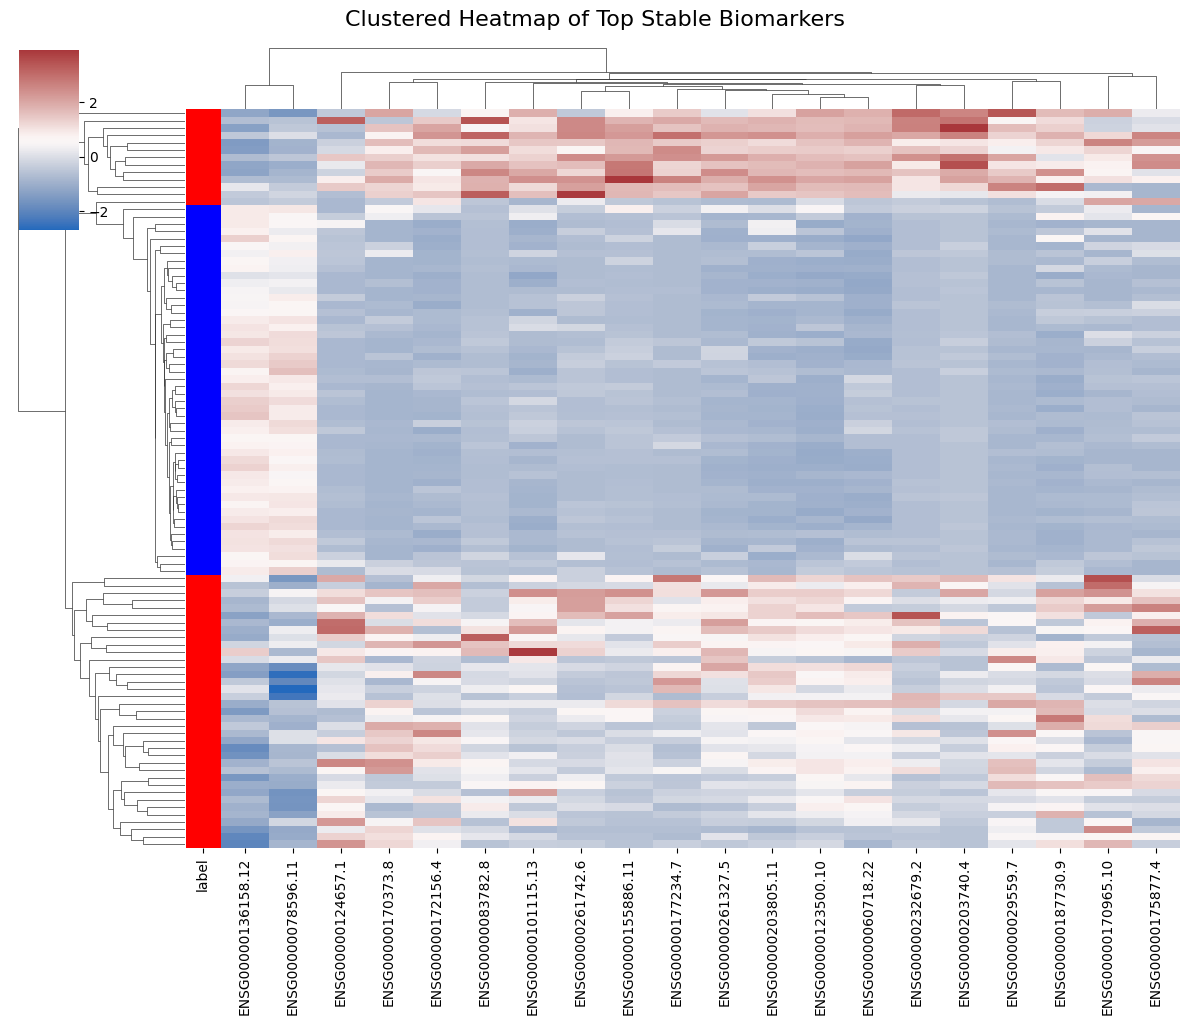

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(
    expression_scaled,
    row_colors=sample_colors,
    cmap='vlag',
    figsize=(12,10),
    xticklabels=True,
    yticklabels=False,
    dendrogram_ratio=(0.15, 0.08)
)

g.fig.suptitle(
    "Clustered Heatmap of Top Stable Biomarkers",
    y=1.02,
    fontsize=16
)

plt.savefig(
    "top_biomarker_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [28]:


from google.colab import files

files.download(
    "top_biomarker_heatmap.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Converting the gene_id into symbols

In [29]:
!pip install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00


In [30]:
import mygene


In [31]:
stable_biomarkers = pd.read_csv(
    "/content/stable_biomarkers.csv"
)

stable_biomarkers.head()

,gene,count
0,ENSG00000029559.7,5
1,ENSG00000232679.2,5
2,ENSG00000261742.6,5
3,ENSG00000170965.10,5
4,ENSG00000155886.11,5


In [32]:
stable_biomarkers['gene_clean'] = (
    stable_biomarkers['gene']
    .str.split('.')
    .str[0]
)

In [33]:
mg = mygene.MyGeneInfo()

In [34]:
gene_info = mg.querymany(
    stable_biomarkers['gene_clean'].tolist(),
    scopes='ensembl.gene',
    fields='symbol,name',
    species='human'
)

INFO:biothings.client:querying 1-156 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


In [35]:
gene_info_df = pd.DataFrame(gene_info)

gene_info_df.head()

,query,_id,_score,name,symbol,notfound
0,ENSG00000029559,3381,31.898120,integrin binding sialoprotein,IBSP,NaN
1,ENSG00000232679,105372950,32.905186,long intergenic non-protein coding RNA 2257,LINC02257,NaN
2,ENSG00000261742,283867,32.905178,long intergenic non-protein coding RNA 922,LINC00922,NaN
3,ENSG00000170965,10761,32.905186,placenta enriched 1,PLAC1,NaN
4,ENSG00000155886,25769,31.898115,solute carrier family 24 member 2,SLC24A2,NaN


In [36]:
gene_symbols_df = gene_info_df[
    ['query', 'symbol', 'name']
]

In [37]:
stable_biomarkers_annotated = stable_biomarkers.merge(
    gene_symbols_df,
    left_on='gene_clean',
    right_on='query',
    how='left'
)

In [38]:
stable_biomarkers_annotated[
    ['gene', 'symbol', 'name', 'count']
].head(20)

,gene,symbol,name,count
0,ENSG00000029559.7,IBSP,integrin binding sialoprotein,5
1,ENSG00000232679.2,LINC02257,long intergenic non-protein coding RNA 2257,5
2,ENSG00000261742.6,LINC00922,long intergenic non-protein coding RNA 922,5
3,ENSG00000170965.10,PLAC1,placenta enriched 1,5
4,ENSG00000155886.11,SLC24A2,solute carrier family 24 member 2,5
5,ENSG00000123500.10,COL10A1,collagen type X alpha 1 chain,5
6,ENSG00000177234.7,LINC01561,long intergenic non-protein coding RNA 1561,5
7,ENSG00000187730.9,GABRD,gamma-aminobutyric acid type A receptor subuni...,5
8,ENSG00000136158.12,SPRY2,sprouty RTK signaling antagonist 2,5
9,ENSG00000060718.22,COL11A1,collagen type XI alpha 1 chain,5


In [39]:
stable_biomarkers_annotated.to_csv(
    "stable_biomarkers_annotated.csv",
    index=False
)

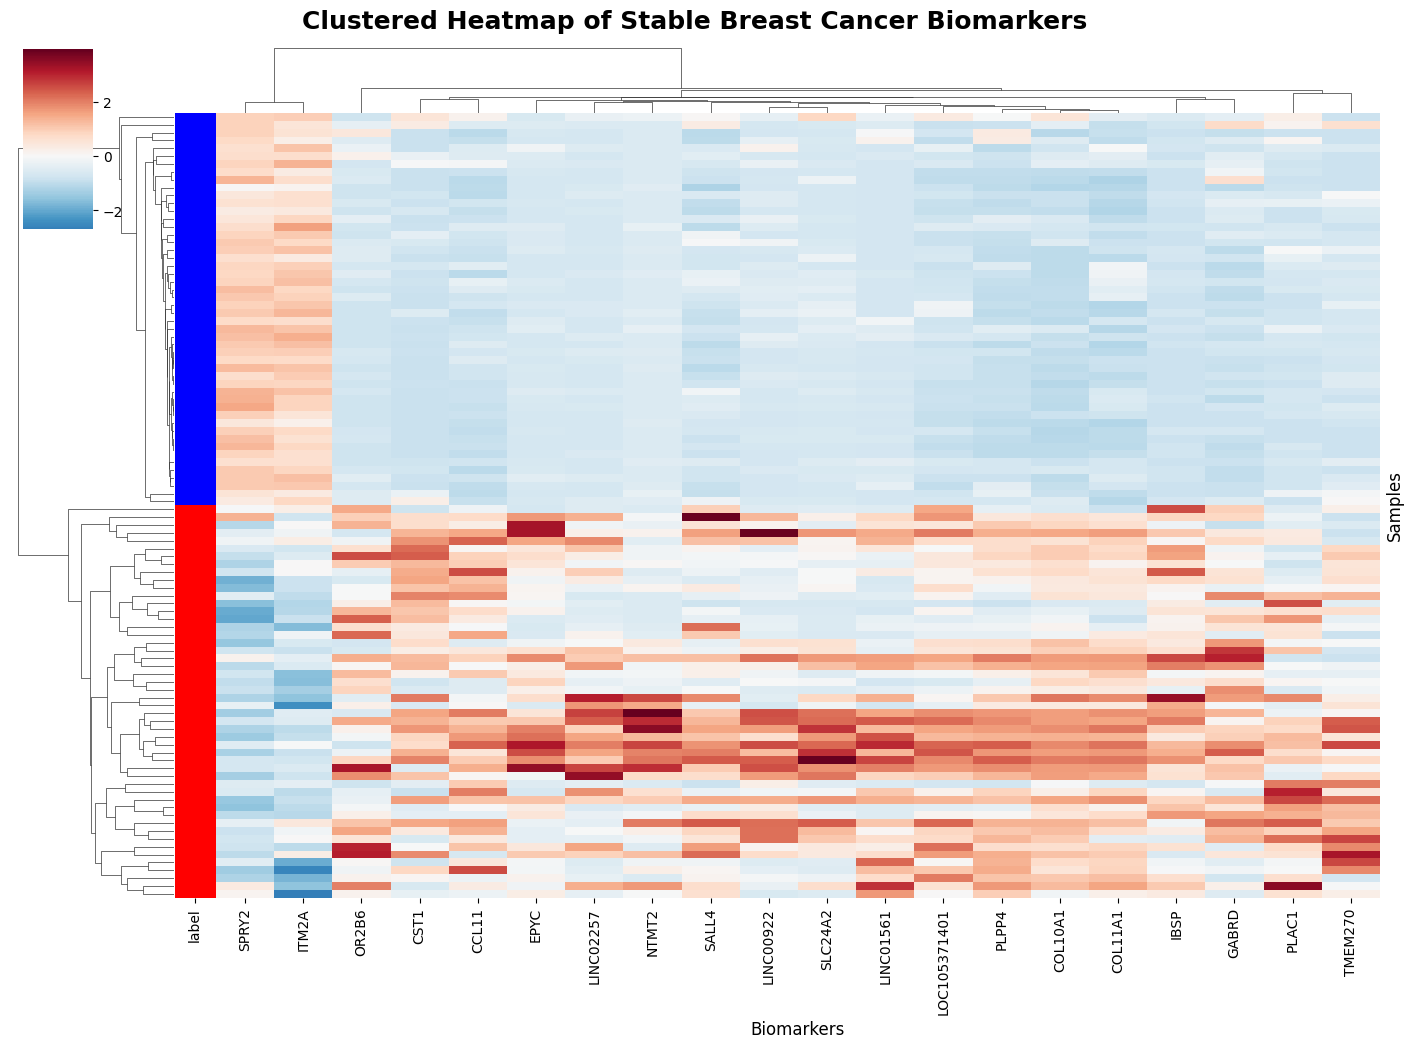

In [41]:
# =========================================================
# RENAME ENSG IDS TO GENE SYMBOLS
# =========================================================
gene_mapping = dict(
    zip(
        stable_biomarkers_annotated['gene'],
        stable_biomarkers_annotated['symbol']
    )
)

expression_scaled = expression_scaled.rename(
    columns=gene_mapping
)

# =========================================================
# CLUSTERED HEATMAP
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(
    expression_scaled,

    # Sample annotation colors
    row_colors=sample_colors,

    # Better genomics color palette
    cmap='RdBu_r',

    # Figure size
    figsize=(14,10),

    # Labels
    xticklabels=True,
    yticklabels=False,

    # Better clustering proportions
    dendrogram_ratio=(0.12, 0.08),

    # Thin grid lines
    linewidths=0,

    # Standard scaling visualization
    center=0,

    # Correlation-based clustering
    metric='correlation',

    # Hierarchical clustering method
    method='average'
)

# =========================================================
# TITLE
# =========================================================

g.fig.suptitle(
    "Clustered Heatmap of Stable Breast Cancer Biomarkers",
    y=1.02,
    fontsize=18,
    fontweight='bold'
)

# =========================================================
# AXIS LABELS
# =========================================================

g.ax_heatmap.set_xlabel(
    "Biomarkers",
    fontsize=12
)

g.ax_heatmap.set_ylabel(
    "Samples",
    fontsize=12
)

# =========================================================
# SAVE FIGURE
# =========================================================

plt.savefig(
    "top_biomarker_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# PCA


In [51]:
stable_biomarkers = pd.read_csv(
    "/content/stable_biomarkers_annotated.csv"
)

stable_biomarkers.head()

,gene,count,gene_clean,query,symbol,name
0,ENSG00000029559.7,5,ENSG00000029559,ENSG00000029559,IBSP,integrin binding sialoprotein
1,ENSG00000232679.2,5,ENSG00000232679,ENSG00000232679,LINC02257,long intergenic non-protein coding RNA 2257
2,ENSG00000261742.6,5,ENSG00000261742,ENSG00000261742,LINC00922,long intergenic non-protein coding RNA 922
3,ENSG00000170965.10,5,ENSG00000170965,ENSG00000170965,PLAC1,placenta enriched 1
4,ENSG00000155886.11,5,ENSG00000155886,ENSG00000155886,SLC24A2,solute carrier family 24 member 2


In [52]:
top20_genes = stable_biomarkers.head(20)['gene'].tolist()

In [53]:
gene_mapping = dict(
    zip(
        stable_biomarkers['gene'],
        stable_biomarkers['symbol']
    )
)

In [54]:
pca_df = df[top20_genes].copy()

pca_df['label'] = df['label']

In [55]:
pca_df['sample_type'] = pca_df['label'].map({
    1: 'Tumor',
    0: 'Normal'
})

In [56]:
X_pca = pca_df[top20_genes]

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_pca)

In [59]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    X_scaled
)

In [60]:
pca_results = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2']
)

pca_results['sample_type'] = pca_df['sample_type'].values

In [61]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.4417456  0.11864997]


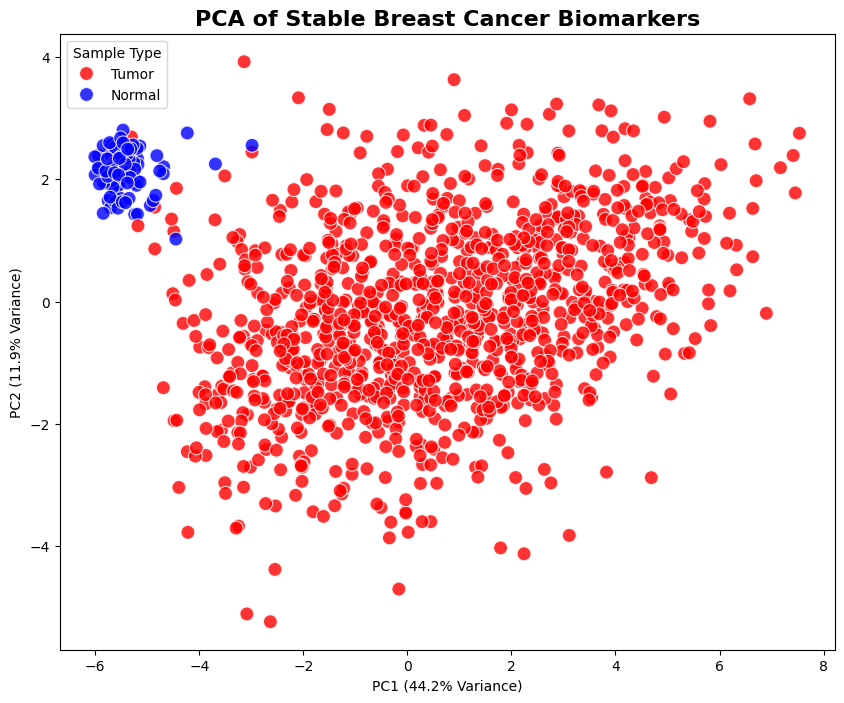

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_results,
    x='PC1',
    y='PC2',
    hue='sample_type',
    palette={
        'Tumor': 'red',
        'Normal': 'blue'
    },
    s=100,
    alpha=0.8
)

plt.xlabel(
    f"PC1 ({explained_variance[0]*100:.1f}% Variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1]*100:.1f}% Variance)"
)

plt.title(
    "PCA of Stable Breast Cancer Biomarkers",
    fontsize=16,
    fontweight='bold'
)

plt.legend(title='Sample Type')

plt.savefig(
    "pca_biomarker_plot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()